> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Data Description

The dataset for this lab consists of **YouTube metadata and thematic features** of Super Bowl commercials, originally sourced from [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

Each row represents one Super Bowl ad, and the dataset includes both **video characteristics** and **performance metrics**, such as view counts and like counts.

Below are key variables we'll work with:

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [1]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[15 12]
 [ 8 10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.56      0.60        27
           1       0.45      0.56      0.50        18

    accuracy                           0.56        45
   macro avg       0.55      0.56      0.55        45
weighted avg       0.57      0.56      0.56        45

Accuracy: 0.5555555555555556


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [6]:
# Use reduced feature set (remove celebrity and funny)
X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]
y = youtube['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))


Confusion Matrix:
 [[13 14]
 [ 9  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45

Accuracy: 0.4888888888888889


### ✍️ Your Response: 🔧
1. the model with a 20% test split using all original features performed better, with a higher accuracy, about 55%. This likely happened because having more training data helped the model learn better pattrns, and keeping relevant features like celebrity and funny kept important infomration that we used to predict.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [7]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [10]:
# Try different SVM kernels and C values

# Change kernel here: 'linear' or 'poly'
svm_model = SVC(kernel='linear', C=10)

# Train model
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[20 18]
 [15 15]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.53      0.55        38
           1       0.45      0.50      0.48        30

    accuracy                           0.51        68
   macro avg       0.51      0.51      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### ✍️ Your Response: 🔧
1. Higher values of C reduce training errors by fitting the data more tightly but increase the risk of overfitting, while lower C values allow more training errors to create a wider margin and better generalization from the model. From what I just tested, when C equals 10 the best accuracy is produced compared to lower values like 0.1 and 1.

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model with Dropout and adjustable layers
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_svm.shape[1],)),  # Layer 1 (try 16, 32, 64)
    Dropout(0.3),                                                      # Dropout 1
    Dense(16, activation='relu'),                                      # Layer 2 (try removing/changing units)
    Dropout(0.3),                                                      # Dropout 2                                       # Layer 3 (optional – try removing)
    Dense(1, activation='sigmoid')                                     # Output Layer
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_svm, y_train_svm,
    validation_data=(X_test_svm, y_test_svm),
    epochs=20,
    batch_size=32,   # <- try 8, 16, 32, etc.
    verbose=1
)


# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.5159 - loss: 0.7543 - val_accuracy: 0.5588 - val_loss: 0.6910
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5020 - loss: 0.7822 - val_accuracy: 0.5735 - val_loss: 0.6915
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5437 - loss: 0.7181 - val_accuracy: 0.5588 - val_loss: 0.6943
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6294 - loss: 0.6740 - val_accuracy: 0.5147 - val_loss: 0.6983
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5573 - loss: 0.6856 - val_accuracy: 0.5147 - val_loss: 0.7025
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5327 - loss: 0.7234 - val_accuracy: 0.5588 - val_loss: 0.7071
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6029 - loss: 0.6662 - val_accuracy: 0.5294 - val_loss: 0.7132
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5528 - loss: 0.6969 - val_accuracy: 0.4706 - val_loss: 0.7187


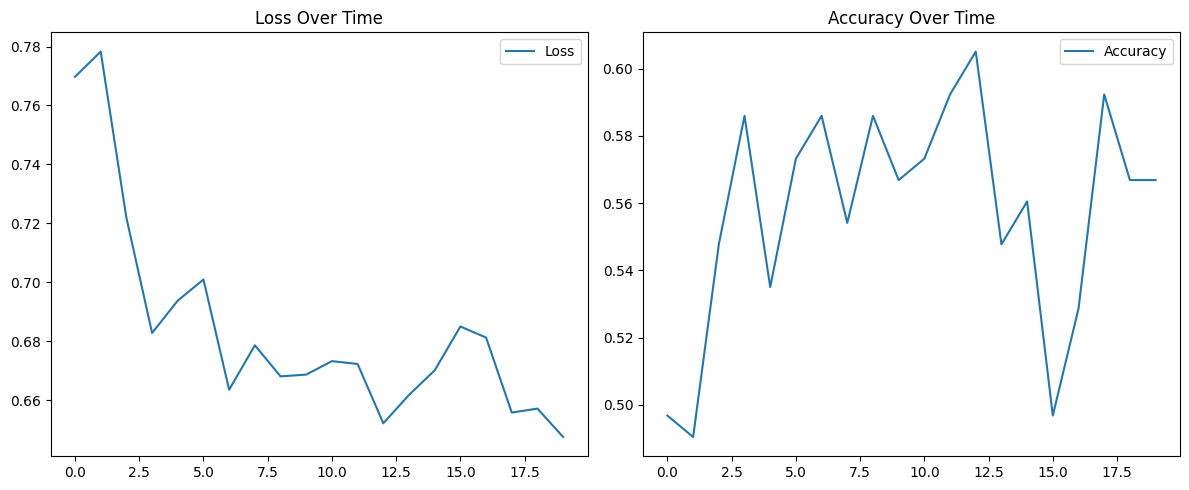

In [18]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.


Config 1: 64-16, dropout 0.3, batch 32
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5224 - loss: 0.7368 - val_accuracy: 0.3971 - val_loss: 0.7387
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4731 - loss: 0.7364 - val_accuracy: 0.4118 - val_loss: 0.7378
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5220 - loss: 0.6992 - val_accuracy: 0.4265 - val_loss: 0.7369
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5297 - loss: 0.7003 - val_accuracy: 0.4118 - val_loss: 0.7381
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5524 - loss: 0.7066 - val_accuracy: 0.3971 - val_loss: 0.7374
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5323 - loss: 0.6817 - val_accuracy: 0.3971 - val_loss: 0.7389
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5455 - loss: 0.6592 - val_accuracy: 0.3824 - val_loss: 0.7408
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6175 - loss: 0.6769 - val_accuracy: 0.3824 - val_loss: 0.7411
Epoch 9/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4150 - loss: 0.7230 - val_accuracy: 0.5294 - val_loss: 0.6905
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5952 - loss: 0.6945 - val_accuracy: 0.5294 - val_loss: 0.6936
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5221 - loss: 0.7067 - val_accuracy: 0.5147 - val_loss: 0.6959
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5750 - loss: 0.6899 - val_accuracy: 0.5147 - val_loss: 0.6991
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5295 - loss: 0.6906 - val_accuracy: 0.5294 - val_loss: 0.7034
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5695 - loss: 0.6986 - val_accuracy: 0.4853 - val_loss: 0.7078
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5098 - loss: 0.6793 - val_accuracy: 0.5294 - val_loss: 0.7123
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5100 - loss: 0.7155 - val_accuracy: 0.5294 - val_loss: 0.

...

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.4868 - loss: 0.7633 - val_accuracy: 0.4706 - val_loss: 0.7464
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4768 - loss: 0.7882 - val_accuracy: 0.4706 - val_loss: 0.7427
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4725 - loss: 0.7595 - val_accuracy: 0.4853 - val_loss: 0.7396
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4511 - loss: 0.8032 - val_accuracy: 0.4706 - val_loss: 0.7370
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5324 - loss: 0.7309 - val_accuracy: 0.4706 - val_loss: 0.7351
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5096 - loss: 0.7231 - val_accuracy: 0.4706 - val_loss: 0.7333
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5350 - loss: 0.7159 - val_accuracy: 0.4559 - val_loss: 0.7319
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5742 - loss: 0.6901 - val_accuracy: 0.4559 - val_loss: 0.7309
Epoch 9/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5181 - loss: 0.7134 - val_accuracy: 0.4412 - val_loss: 0.7006
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5502 - loss: 0.7182 - val_accuracy: 0.4412 - val_loss: 0.7040
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5442 - loss: 0.7359 - val_accuracy: 0.4559 - val_loss: 0.7067
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5470 - loss: 0.7122 - val_accuracy: 0.4265 - val_loss: 0.7081
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5085 - loss: 0.7019 - val_accuracy: 0.4559 - val_loss: 0.7081
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5052 - loss: 0.7348 - val_accuracy: 0.4412 - val_loss: 0.7083
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4863 - loss: 0.7685 - val_accuracy: 0.4559 - val_loss: 0.7074
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4344 - loss: 0.7154 - val_accuracy: 0.4559 - val_loss: 0.7

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4600 - loss: 0.7506 - val_accuracy: 0.4559 - val_loss: 0.7606
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6085 - loss: 0.7847 - val_accuracy: 0.4559 - val_loss: 0.7493
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5070 - loss: 0.7203 - val_accuracy: 0.4559 - val_loss: 0.7467
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4454 - loss: 0.7556 - val_accuracy: 0.4412 - val_loss: 0.7412
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5738 - loss: 0.6780 - val_accuracy: 0.4559 - val_loss: 0.7386
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5114 - loss: 0.7221 - val_accuracy: 0.4412 - val_loss: 0.7384
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6032 - loss: 0.6753 - val_accuracy: 0.4265 - val_loss: 0.7388
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5982 - loss: 0.6904 - val_accuracy: 0.4265 - val_loss: 0.7403
Ep

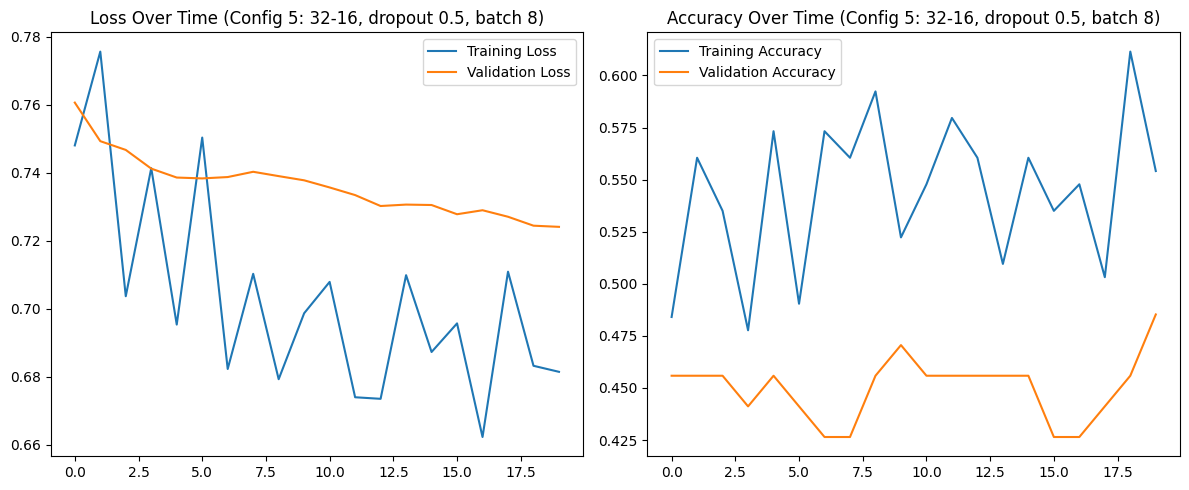

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Make sure X_train_svm, X_test_svm, y_train_svm, y_test_svm are already defined

configs = [
    {"name": "Config 1: 64-16, dropout 0.3, batch 32", "layers": [64, 16], "dropout": 0.3, "batch_size": 32},
    {"name": "Config 2: 32-16-8, dropout 0.3, batch 16", "layers": [32, 16, 8], "dropout": 0.3, "batch_size": 16},
    {"name": "Config 3: 16 only, dropout 0.3, batch 32", "layers": [16], "dropout": 0.3, "batch_size": 32},
    {"name": "Config 4: 64-32-16, dropout 0.5, batch 16", "layers": [64, 32, 16], "dropout": 0.5, "batch_size": 16},
    {"name": "Config 5: 32-16, dropout 0.5, batch 8",  "layers": [32, 16], "dropout": 0.5, "batch_size": 8},
]

histories = {}
results = []

for cfg in configs:
    print("=" * 70)
    print(cfg["name"])

    # Build model dynamically based on config
    model_layers = [
        Dense(cfg["layers"][0], activation='relu', input_shape=(X_train_svm.shape[1],)),
        Dropout(cfg["dropout"])
    ]

    for units in cfg["layers"][1:]:
        model_layers.append(Dense(units, activation='relu'))
        model_layers.append(Dropout(cfg["dropout"]))

    model_layers.append(Dense(1, activation='sigmoid'))

    model = Sequential(model_layers)

    # Compile
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train_svm, y_train_svm,
        validation_data=(X_test_svm, y_test_svm),
        epochs=20,
        batch_size=cfg["batch_size"],
        verbose=1
    )

    histories[cfg["name"]] = history

    # Predict and evaluate
    y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)

    print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
    print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
    acc = accuracy_score(y_test_svm, y_pred_nn)
    print("Accuracy:", acc)

    results.append((cfg["name"], acc))

print("\nSummary of configurations and accuracies:")
for name, acc in results:
    print(f"{name}: Accuracy = {acc:.4f}")

# Plot learning curves for the LAST configuration run
last_cfg_name = configs[-1]["name"]
history = histories[last_cfg_name]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history.get('val_loss', []), label='Validation Loss')
plt.title(f'Loss Over Time ({last_cfg_name})')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')
plt.title(f'Accuracy Over Time ({last_cfg_name})')
plt.legend()

plt.tight_layout()
plt.show()


### ✍️ Your Response: 🔧
1. the best setup that I found was three layers 32-16-8 unites with batche size 16 and dropout of 0.3, which gave the highest accuracy.

2. Adding Dropout helped reduce overfitting. In the loss over time plots, training loss continued to decrease, but validation loss stayed more stable and didn't blow up as quickly as in the earlier network without any dropout. The gap between training and validation curves was smaller, indicating that there is better generalization.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. The bets performing model was the neural network with dropout layers of 32 16 and 8 with batch size 16, which acheived the highest accuracy. This was somewhat unexpected, as I thought SVM would perform the best.
2. The original neural network clearly showed overfitting, as training accuracy go better while vaidation accuracy stayed flat and validation loss increased. Some SVM and Naive Bayes models underfit becuase their accuracies stayed close to random guessing.

3. I would reccomend the NN with dropout becuase it achieved the best accuracy and handled non linear relationships better. It also provides more flexibility to improve with more data and features in real marketing applications.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [21]:
!jupyter nbconvert --to html "lab_12_WoodMason.ipynb"

[NbConvertApp] Converting notebook lab_12_WoodMason.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 582913 bytes to lab_12_WoodMason.html
